In [1]:
# This cell is removed with the tag: "remove-input"
# As such, it will not be shown in documentation

import warnings
warnings.filterwarnings('ignore')


(Tutorial_Least_rmsd_fit)=
# Least RMSD fit

*Superposing a molecular system onto a reference structure using the Kabsch algorithm.*

The function {func}`molsysmt.structure.least_rmsd_fit` rotates and translates a molecular system (or every frame of a trajectory) to minimize the root-mean-square deviation of a chosen atom selection relative to a reference structure.

:::{versionadded} 1.0.0
:::

:::{admonition} API documentation
:class: dropdown

Follow this link for a detailed description of the input arguments, raised errors, and returned objects of this function: {func}`molsysmt.structure.least_rmsd_fit`.
:::


## Basic usage

Let's show how to fit all frames of a pentalanine trajectory onto its initial frame using backbone atoms:


In [2]:
import molsysmt as msm
import matplotlib.pyplot as plt
import pyunitwizard as puw


In [3]:
molsys = msm.convert(msm.systems['pentalanine']['traj_pentalanine.h5msm'])


:::{note} Demo Systems Catalog
:class: dropdown

This tutorial uses demonstration datasets provided by MolSysMT. To explore the full catalog of bundled systems, forms, and file paths, visit the {ref}`Demo Systems <user-foundations-entrance-demo-systems>` guide.
:::


We fit the trajectory using {func}`molsysmt.structure.least_rmsd_fit` specifying `selection_fit='backbone'`:


In [4]:
molsys_fitted = msm.structure.least_rmsd_fit(molsys, selection='all', selection_fit='backbone', reference_structure_index=0)


## Verifying alignment with get_rmsd

When we compute the raw unaligned RMSD on `molsys_fitted`, it precisely matches the theoretical minimum RMSD computed by `get_least_rmsd`:


In [5]:
rmsd_fitted = msm.structure.get_rmsd(molsys_fitted, selection='backbone', reference_structure_index=0)
rmsd_least = msm.structure.get_least_rmsd(molsys, selection='backbone', reference_structure_index=0)

print(f'Fitted RMSD at frame 1: {rmsd_fitted[1]:.4f}')
print(f'Theoretical Least RMSD at frame 1: {rmsd_least[1]:.4f}')


Fitted RMSD at frame 1: 0.1259 nanometer
Theoretical Least RMSD at frame 1: 0.1259 nanometer


## Plotting fitted trajectory RMSD

We plot the RMSD time series before and after least-RMSD fitting to visualize the removal of rotational and translational drift:


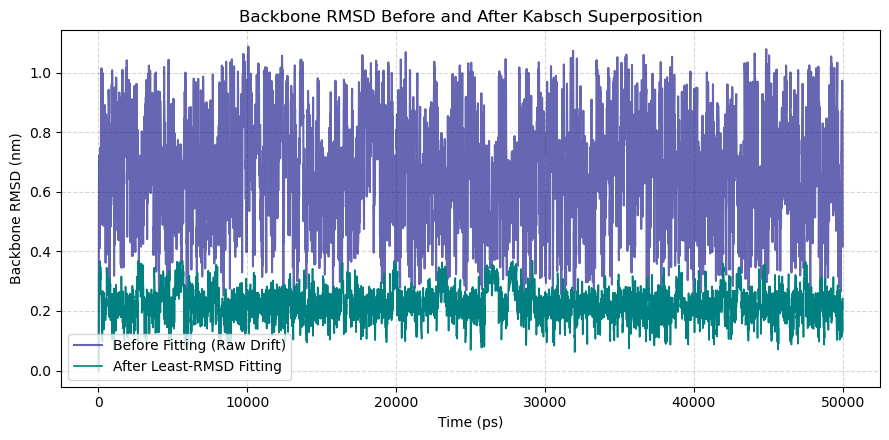

In [6]:
time = msm.get(molsys, element='system', time=True)
time_val = puw.get_value(time, to_unit='ps')
rmsd_raw = msm.structure.get_rmsd(molsys, selection='backbone', reference_structure_index=0)

plt.figure(figsize=(9, 4.5))
plt.plot(time_val, puw.get_value(rmsd_raw, to_unit='nm'), color='navy', alpha=0.6, label='Before Fitting (Raw Drift)')
plt.plot(time_val, puw.get_value(rmsd_fitted, to_unit='nm'), color='teal', lw=1.2, label='After Least-RMSD Fitting')
plt.xlabel('Time (ps)')
plt.ylabel('Backbone RMSD (nm)')
plt.title('Backbone RMSD Before and After Kabsch Superposition')
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.tight_layout()
plt.show()


:::{seealso} Related Tools & References
:class: dropdown

- {ref}`Convert <Tutorial_Convert>`: Convert molecular systems between different forms with {func}`molsysmt.basic.convert`.
- {ref}`Get <Tutorial_Get>`: Query system time and structural attributes with {func}`molsysmt.basic.get`.
- {ref}`Get RMSD <Tutorial_Get_rmsd>`: Compute unaligned root-mean-square deviations with {func}`molsysmt.structure.get_rmsd`.
- {ref}`Get least RMSD <Tutorial_Get_least_rmsd>`: Calculate optimal superposition RMSD values with {func}`molsysmt.structure.get_least_rmsd`.
- {ref}`Least RMSD align <Tutorial_Least_rmsd_align>`: Sequence-guided alignment for disparate topologies with {func}`molsysmt.structure.least_rmsd_align`.
:::
